In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from os import listdir

%matplotlib inline

In [ ]:
import zipfile
import os

# Extract archive.zip which typically contains the 'yes' and 'no' folders
zip_path = '/content/archive.zip'
extract_path = '/content/'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed successfully!")
else:
    print(f"Error: {zip_path} not found.")

Extraction completed successfully!


In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'drive', 'archive.zip', 'yes', 'Augmented.zip', 'brain_tumor_dataset', 'no', 'sample_data']


In [ ]:
def crop_brain_contour(image, plot=False):

    #import imutils
    #import cv2
    #from matplotlib import pyplot as plt

    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)


    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure()

        plt.subplot(1, 2, 1)
        plt.imshow(image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')

        plt.show()

    return new_image

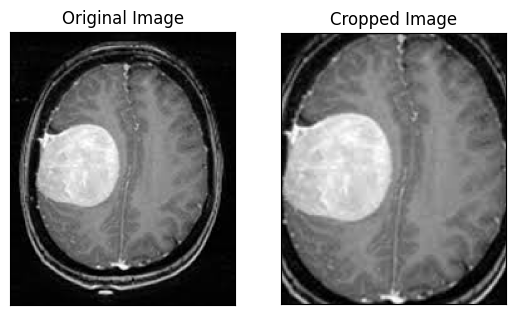

In [ ]:
import os

image_path = '/content/yes/Y1.jpg'
ex_img = cv2.imread(image_path)

if ex_img is None:
    print(f"Error: Could not load image at {image_path}.")
    if os.path.exists('/content/yes'):
        print("Files in /content/yes/:", os.listdir('/content/yes')[:5])
    else:
         print("/content/yes directory does not exist.")
else:
    # OpenCV loads images as BGR, we convert to RGB for proper plotting with matplotlib
    ex_img_rgb = cv2.cvtColor(ex_img, cv2.COLOR_BGR2RGB)
    ex_new_img = crop_brain_contour(ex_img_rgb, True)

In [ ]:
def load_data(dir_list, image_size):
    """
    Read images, resize and normalize them.
    Arguments:
        dir_list: list of strings representing file directories.
    Returns:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        for filename in listdir(directory):
            # load the image
            image = cv2.imread(directory + '\\' + filename)
            # crop the brain and ignore the unnecessary rest part of the image
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)
            # append a value of 1 to the target array if the image
            # is in the folder named 'yes', otherwise append 0.
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])

    X = np.array(X)
    y = np.array(y)

    # Shuffle the data
    X, y = shuffle(X, y)

    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')

    return X, y

In [ ]:
import zipfile
import os
import glob

# 1. Extract Augmented.zip if not already extracted
augmented_zip = '/content/Augmented.zip'
if os.path.exists(augmented_zip) and not os.path.exists('/content/augmented_extracted_marker'):
    with zipfile.ZipFile(augmented_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/augmented_extracted/')
    # Create a marker file to avoid re-extracting
    with open('/content/augmented_extracted_marker', 'w') as f:
        f.write('extracted')
    print("Augmented.zip extracted successfully!")

# 2. Dynamically locate 'yes' and 'no' folders inside the extracted structure
paths_found = glob.glob('/content/augmented_extracted/**/yes', recursive=True)
if not paths_found:
    # Fallback to check case-insensitive match or check root folder
    paths_found = glob.glob('/content/augmented_extracted/**/[Yy][Ee][Ss]', recursive=True)

if paths_found:
    augmented_yes = paths_found[0]
    # Replace 'yes' with 'no' at the end of the path to get the 'no' directory
    augmented_no = os.path.join(os.path.dirname(augmented_yes), os.path.basename(augmented_yes).replace('yes', 'no').replace('YES', 'NO'))
    if not os.path.exists(augmented_no):
        augmented_no = glob.glob('/content/augmented_extracted/**/[Nn][Oo]', recursive=True)[0]
    print(f"Located folders:\n YES: {augmented_yes}\n NO: {augmented_no}")
else:
    raise FileNotFoundError("Could not locate the 'yes' and 'no' folders inside extracted zip.")

IMG_WIDTH, IMG_HEIGHT = (240, 240)

# 3. Workaround for Linux/Windows backslash discrepancy in load_data
import cv2
original_imread = cv2.imread
def linux_compatible_imread(path, *args, **kwargs):
    normalized_path = path.replace('\\', '/')
    return original_imread(normalized_path, *args, **kwargs)
cv2.imread = linux_compatible_imread

try:
    X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))
finally:
    # Restore original imread
    cv2.imread = original_imread

Augmented.zip extracted successfully!
Located folders:
 YES: /content/augmented_extracted/yes
 NO: /content/augmented_extracted/no
Number of examples is: 2065
X shape is: (2065, 240, 240, 3)
y shape is: (2065, 1)


In [ ]:
def plot_sample_images(X, y, n=50):


    for label in [0,1]:
        images = X[np.argwhere(y == label)]
        n_images = images[:n]

        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))

        i = 1
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])

            plt.tick_params(axis='both', which='both',
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)

            i += 1

        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

In [ ]:
plot_sample_images(X, y)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
def split_data(X, y, test_size=0.2):

    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [ ]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 1445
number of development examples = 310
number of test examples = 310
X_train shape: (1445, 240, 240, 3)
Y_train shape: (1445, 1)
X_val (dev) shape: (310, 240, 240, 3)
Y_val (dev) shape: (310, 1)
X_test shape: (310, 240, 240, 3)
Y_test shape: (310, 1)


In [ ]:
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [ ]:
def compute_f1_score(y_true, prob):
    y_pred = np.where(prob > 0.5, 1, 0)

    score = f1_score(y_true, y_pred)

    return score

In [ ]:
def build_model(input_shape):
    X_input = Input(input_shape)
    X = ZeroPadding2D((2, 2))(X_input)
    X = Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = 'bn0')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((4, 4), name='max_pool0')(X)
    X = MaxPooling2D((4, 4), name='max_pool1')(X)
    X = Flatten()(X)
    X = Dense(1, activation='sigmoid', name='fc')(X)
    model = Model(inputs = X_input, outputs = X, name='BrainDetectionModel')
    return model

In [ ]:
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

In [ ]:
model = build_model(IMG_SHAPE)

In [ ]:
model.summary()

Model: "BrainDetectionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 238, 238, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 238, 238, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 238, 238, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool0 (MaxPooling2D)        │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [ ]:
import os
os.makedirs('models', exist_ok=True)
filepath = "cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}.keras"
checkpoint = ModelCheckpoint(
    filepath="models/" + filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5886 - loss: 1.0475
Epoch 1: val_accuracy improved from None to 0.60968, saving model to models/cnn-parameters-improvement-01-0.61.keras

Epoch 1: finished saving model to models/cnn-parameters-improvement-01-0.61.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.6242 - loss: 0.8264 - val_accuracy: 0.6097 - val_loss: 0.6572
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7356 - loss: 0.5404
Epoch 2: val_accuracy improved from 0.60968 to 0.64839, saving model to models/cnn-parameters-improvement-02-0.65.keras

Epoch 2: finished saving model to models/cnn-parameters-improvement-02-0.65.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.7336 - loss: 0.5360 - val_accuracy: 0.6484 - val_loss: 0.6128
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7445 - loss: 0.5108
Epoch 3: val_accuracy improved from 0.64839 to 0.72258, saving model to models/cnn-parameters-improvement-03-0.72.ke

In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9121 - loss: 0.2215
Epoch 1: val_accuracy did not improve from 0.86452
46/46 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.9260 - loss: 0.2023 - val_accuracy: 0.7323 - val_loss: 0.6053
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9241 - loss: 0.1990
Epoch 2: val_accuracy did not improve from 0.86452
46/46 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9260 - loss: 0.1980 - val_accuracy: 0.8452 - val_loss: 0.3447
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9419 - loss: 0.1670
Epoch 3: val_accuracy did not improve from 0.86452
46/46 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.9370 - loss: 0.1804 - val_accuracy: 0.7742 - val_loss: 0.5087
Elapsed time: 0:9:32.1


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9199 - loss: 0.1957
Epoch 1: val_accuracy did not improve from 0.86452
46/46 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9287 - loss: 0.1813 - val_accuracy: 0.7871 - val_loss: 0.4908
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9530 - loss: 0.1453
Epoch 2: val_accuracy did not improve from 0.86452
46/46 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.9488 - loss: 0.1493 - val_accuracy: 0.8645 - val_loss: 0.3485
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9518 - loss: 0.1433
Epoch 3: val_accuracy improved from 0.86452 to 0.87419, saving model to models/cnn-parameters-improvement-03-0.87.keras

Epoch 3: finished saving model to models/cnn-parameters-improvement-03-0.87.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.9557 - loss: 0.1395 - val_accuracy: 0.8742 - val_loss: 0.3342
Elapsed time: 0:9:41.4


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9428 - loss: 0.1615
Epoch 1: val_accuracy did not improve from 0.87419
46/46 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9592 - loss: 0.1354 - val_accuracy: 0.8710 - val_loss: 0.3236
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9801 - loss: 0.0996
Epoch 2: val_accuracy did not improve from 0.87419
46/46 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9668 - loss: 0.1159 - val_accuracy: 0.7452 - val_loss: 0.7367
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9518 - loss: 0.1380
Epoch 3: val_accuracy did not improve from 0.87419
46/46 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9599 - loss: 0.1206 - val_accuracy: 0.8645 - val_loss: 0.3346
Elapsed time: 0:9:56.3


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=5, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9773 - loss: 0.1070
Epoch 1: val_accuracy did not improve from 0.87419
46/46 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - accuracy: 0.9606 - loss: 0.1279 - val_accuracy: 0.8484 - val_loss: 0.3768
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9631 - loss: 0.1224
Epoch 2: val_accuracy improved from 0.87419 to 0.89032, saving model to models/cnn-parameters-improvement-02-0.89.keras

Epoch 2: finished saving model to models/cnn-parameters-improvement-02-0.89.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.9626 - loss: 0.1178 - val_accuracy: 0.8903 - val_loss: 0.3253
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9798 - loss: 0.0822
Epoch 3: val_accuracy did not improve from 0.89032
46/46 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.9772 - loss: 0.0858 - val_accuracy: 0.8839 - val_loss: 0.3222
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9614 - loss: 0.1169
Epoch 4: val_accura

In [ ]:
history = model.history.history

In [ ]:
for key in history.keys():
    print(key)

accuracy
loss
val_accuracy
val_loss


In [ ]:
def plot_metrics(history):

    train_loss = history['loss']
    val_loss = history['val_loss']
    train_accuracy = history['accuracy']
    val_accuracy = history['val_accuracy']

    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_accuracy, label='Training Accuracy')
    plt.plot(val_accuracy, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

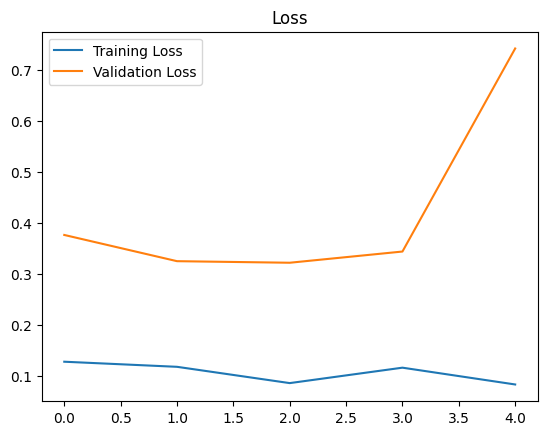

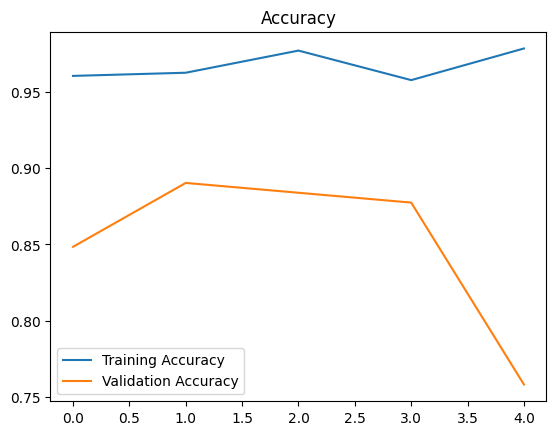

In [ ]:
plot_metrics(history)

In [ ]:
!ls models/

cnn-parameters-improvement-01-0.61.keras
cnn-parameters-improvement-02-0.65.keras
cnn-parameters-improvement-02-0.89.keras
cnn-parameters-improvement-03-0.72.keras
cnn-parameters-improvement-03-0.87.keras
cnn-parameters-improvement-04-0.82.keras
cnn-parameters-improvement-06-0.84.keras
cnn-parameters-improvement-10-0.86.keras


In [ ]:
from keras.models import load_model

best_model = load_model('models/cnn-parameters-improvement-10-0.86.keras')

In [ ]:
best_model.metrics_names

['loss', 'compile_metrics']

In [ ]:
loss, acc = best_model.evaluate(x=X_test, y=y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 758ms/step - accuracy: 0.8613 - loss: 0.3258


In [ ]:
print (f"Test Loss = {loss}")
print (f"Test Accuracy = {acc}")

Test Loss = 0.32577016949653625
Test Accuracy = 0.8612903356552124


In [ ]:
y_test_prob = best_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 998ms/step


In [ ]:
f1score = compute_f1_score(y_test, y_test_prob)
print(f"F1 score: {f1score}")

F1 score: 0.8774928774928775


In [ ]:
y_val_prob = best_model.predict(X_val)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 728ms/step


In [ ]:
f1score_val = compute_f1_score(y_val, y_val_prob)
print(f"F1 score: {f1score_val}")

F1 score: 0.8719512195121951


In [ ]:
def data_percentage(y):

    m=len(y)
    n_positive = np.sum(y)
    n_negative = m - n_positive

    pos_prec = (n_positive* 100.0)/ m
    neg_prec = (n_negative* 100.0)/ m

    print(f"Number of examples: {m}")
    print(f"Percentage of positive examples: {pos_prec}%, number of pos examples: {n_positive}")
    print(f"Percentage of negative examples: {neg_prec}%, number of neg examples: {n_negative}")


In [ ]:
data_percentage(y)

Number of examples: 2065
Percentage of positive examples: 52.54237288135593%, number of pos examples: 1085
Percentage of negative examples: 47.45762711864407%, number of neg examples: 980


In [ ]:
print("Training Data:")
data_percentage(y_train)
print("Validation Data:")
data_percentage(y_val)
print("Testing Data:")
data_percentage(y_test)

Training Data:
Number of examples: 1445
Percentage of positive examples: 51.90311418685121%, number of pos examples: 750
Percentage of negative examples: 48.09688581314879%, number of neg examples: 695
Validation Data:
Number of examples: 310
Percentage of positive examples: 51.935483870967744%, number of pos examples: 161
Percentage of negative examples: 48.064516129032256%, number of neg examples: 149
Testing Data:
Number of examples: 310
Percentage of positive examples: 56.12903225806452%, number of pos examples: 174
Percentage of negative examples: 43.87096774193548%, number of neg examples: 136


In [78]:
import os
import glob
import cv2
import imutils
import numpy as np
from tensorflow.keras.models import load_model

# 1. Automatically locate the best saved .keras model
model_candidates = glob.glob('models/*.keras')

if model_candidates:
    # Picks the best model checkpoint or specifically 10-0.86 if present
    target_path = 'models/cnn-parameters-improvement-10-0.86.keras'
    model_path = target_path if os.path.exists(target_path) else sorted(model_candidates)[-1]
    model = load_model(model_path)
    print(f"Successfully loaded model from: {model_path}")
else:
    raise FileNotFoundError("No .keras files found in 'models/'. Check your directory with: !ls models/")

# 2. Contour cropping function from the notebook
def crop_brain_contour(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #[cite: 1]
    gray = cv2.GaussianBlur(gray, (5, 5), 0) #[cite: 1]
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1] #[cite: 1]
    thresh = cv2.erode(thresh, None, iterations=2) #[cite: 1]
    thresh = cv2.dilate(thresh, None, iterations=2) #[cite: 1]
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #[cite: 1]
    cnts = imutils.grab_contours(cnts) #[cite: 1]
    c = max(cnts, key=cv2.contourArea) #[cite: 1]

    extLeft = tuple(c[c[:, :, 0].argmin()][0]) #[cite: 1]
    extRight = tuple(c[c[:, :, 0].argmax()][0]) #[cite: 1]
    extTop = tuple(c[c[:, :, 1].argmin()][0]) #[cite: 1]
    extBot = tuple(c[c[:, :, 1].argmax()][0]) #[cite: 1]

    cropped = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]] #[cite: 1]
    return cropped, (extLeft, extRight, extTop, extBot)

Successfully loaded model from: models/cnn-parameters-improvement-10-0.86.keras
